# Daily environment report — map, issue and island bars, and a pie for the dominant issue

Where environmental issues are being reported across Indonesia, which issues they are,
and how they distribute across the islands. A choropleth across the top; below it a bar chart
of issue categories, a bar chart of cases per island, and a pie of provinces for the one issue
that towers over the rest. Built with `great.viz.environment`.

## One-time setup

The map needs the `[geo]` extra (geopandas, shapely, requests) on top of the usual install:

```
py -3.11 -m pip install -e "C:\Users\ASUS\Documents\Research Project\GREAT Big Data Analysis Program[all]"
```

`[all]` covers it. If you installed with just `[viz]` earlier, re-run the line above — `great.viz.environment`
imports geopandas at module level and will not import without it.

On first use the module downloads the 38-province GeoJSON once and caches it in your user
directory, so that step only costs you network time the first time.

In [1]:
# Pick up edits to the great/ source without restarting the kernel.
%load_ext autoreload
%autoreload 2

In [2]:
import re

import pandas as pd

from great import classify_issue, resolve_frame, validate_export
from great.viz import prep
from great.viz.environment import dominant_issues, env_bar_pies, island_counts

## 1. Load and validate

The export is read straight from Google Sheets, so the notebook runs on any machine without a
local copy of the file. Paste the sheet's link into `SOURCE` — the file must be shared as
"Anyone with the link". Only the file id in the link matters; it is turned into Google's
`export?format=xlsx` download URL, which pandas reads directly.

The environmental export uses the same 13-column schema as every other export in this
portfolio, so `validate_export()` applies unchanged — it fails at load time if a column is
missing or a Sentiment/Media value falls outside the canonical vocabulary.

In [3]:
SOURCE = 'https://docs.google.com/spreadsheets/d/119b-k0DDykSpZJ-BAmIANWKnlfYLBfho/edit?gid=137764228#gid=137764228'

sheet_id = re.search(r'/spreadsheets/d/([\w-]+)', SOURCE).group(1)
df = pd.read_excel(f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=xlsx', header=1)
df = validate_export(df)

df1, start_date, end_date = prep.prepare_data(df)
print(f'{len(df1):,} rows | {start_date} - {end_date}')

1,832 rows | 23 Sep 2026 - 23 Sep 2026


## 2. Derive `Isu_Inti` and `Provinsi`

Neither column exists in a raw export — both reports need them, and this is where the rest of
the library does the work.

**The issue category** comes from `classify_issue()`, the keyword rules in `great/issues.py`.

**The province** comes from `resolve_frame()`, which scans the headline and
mention text against the 1,243-entry gazetteer in `great/geo.py` and falls back to the
structured `Location` column only for rows the text cannot place.

Text wins deliberately. In this export `Location` is the *author’s* location — measured over
25k rows the two disagree 74% of the time, with `Location="Jakarta"` on articles about fires
in Kalimantan. For a map of where issues are *happening*, the article text is the right
signal.

It returns `Pulau` as well, which the island bar chart uses.

In [4]:
df1['Isu_Inti'] = df1['Mentions'].map(classify_issue)
df1[['Provinsi', 'Pulau']] = resolve_frame(df1)

counts = df1['Provinsi'].value_counts()
unresolved = counts.get('Tidak Terdeteksi', 0) + counts.get('Provinsi Tidak Spesifik', 0)
print(f'resolved to a province: {len(df1) - unresolved:,} of {len(df1):,} '
      f'({(len(df1) - unresolved) / len(df1):.1%})')
counts.head(10)

resolved to a province: 993 of 1,832 (54.2%)


Provinsi
Tidak Terdeteksi           644
Kalimantan Selatan         206
Provinsi Tidak Spesifik    195
Kalimantan Tengah          188
DKI Jakarta                 77
Jawa Barat                  65
Kalimantan Timur            61
Kalimantan Barat            60
Jawa Timur                  54
Riau                        45
Name: count, dtype: int64

In [5]:
df1['Isu_Inti'].value_counts()

Isu_Inti
Kebakaran lingkungan         1447
Polusi udara                  101
Sampah                         52
Pencemaran air/limbah          38
Satwa/ekosistem                34
Konflik agraria                32
Kekeringan/Krisis Air          31
Deforestasi                    20
Tambang ilegal/ekstraktif      18
Banjir/longsor                 16
Noise/Tidak Relevan            13
Isu lingkungan lain            12
Perubahan iklim/emisi           5
Energi terbarukan (EBT)         5
Konservasi/reboisasi            4
Bencana vulkanik                1
Abrasi/erosi                    1
Krisis Energi Nasional          1
Pemulihan Pascabencana          1
Name: count, dtype: int64

## 3. The daily figure

Same layout as the weekly report — `env_bar_pies()`, map across the top, issue breakdown
underneath — with two differences. As in the weekly report, rows classified "Noise/Tidak
Relevan" are dropped first, so they count in neither the bars, the map nor the pie.

**A cases-per-island bar chart.** `island_bars=True` adds it between the issue bars and the
pie. Provinces map to islands through `great.geo.PULAU_MAP`, largest island on top.

**At most one pie.** `max_dominant=1` keeps only the single most lopsided issue. A day's
data is thinner than a week's, and one pie next to two bar charts is as much as the bottom
row holds. Here 1,447 / 101 = 14.3×, well past `dominance_ratio`, so "Kebakaran lingkungan"
leaves the issue chart and gets the pie. On a day with no such gap there is no pie, and the
issue chart shows every issue.

The pie follows the weekly rules: the top nine provinces, the rest as "Lainnya", rows with no
province counted in a note underneath instead of a slice.

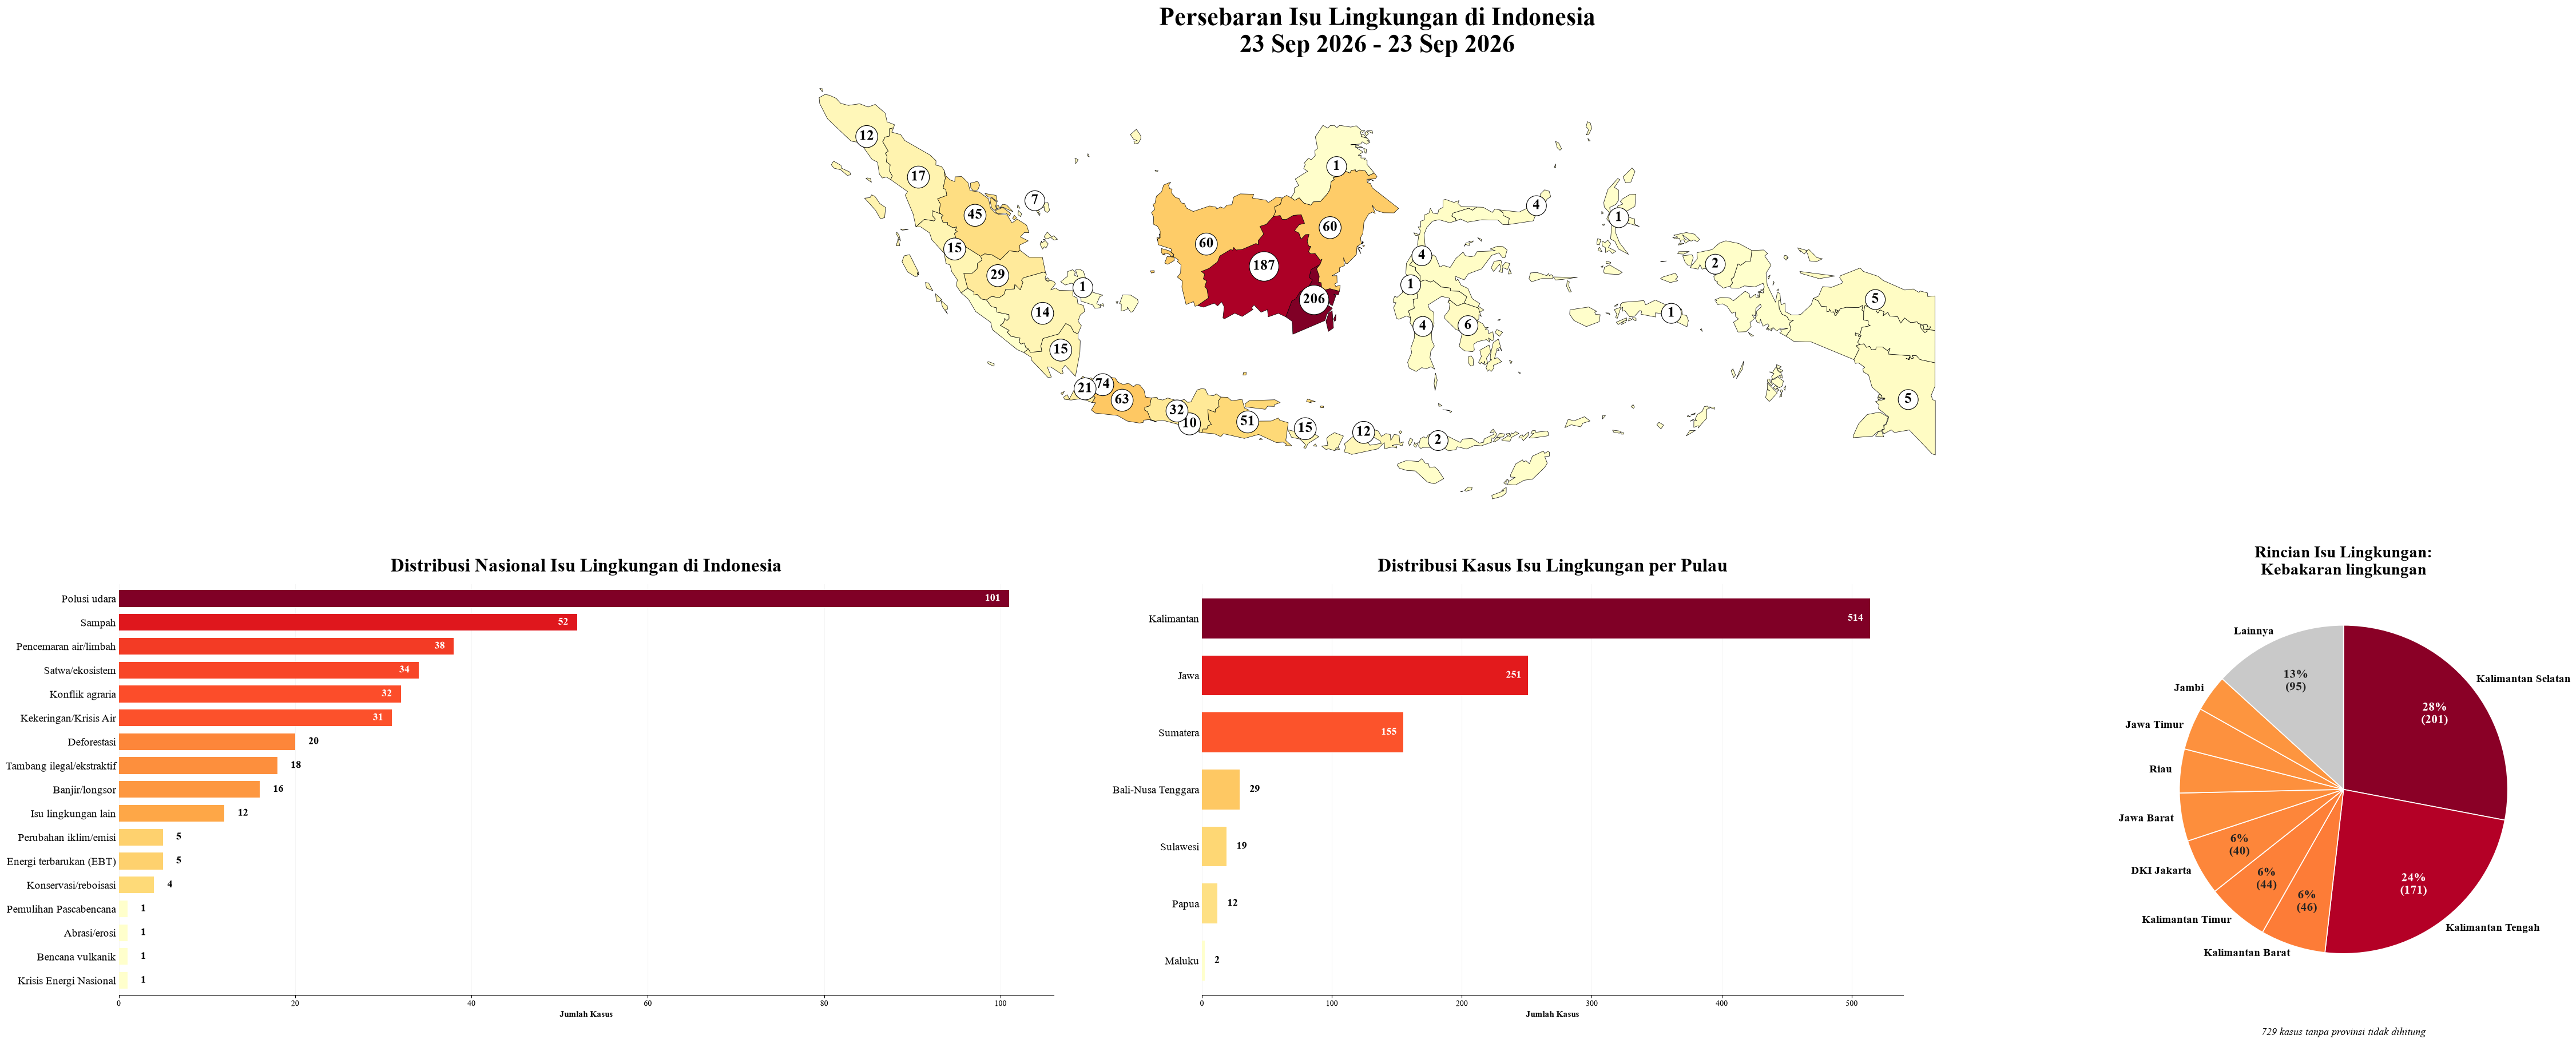

In [6]:
fig = env_bar_pies(
    df1,
    start_date=start_date,
    end_date=end_date,
    island_bars=True,      # the daily extra: cases per island
    max_dominant=1,        # at most one pie, for the most lopsided issue
    dominance_ratio=2.0,   # how lopsided that issue must be before it becomes a pie
)

## 4. The numbers behind the figure

The same aggregations the report uses, available separately when you want the table rather
than the picture.

In [7]:
report = df1[df1['Isu_Inti'] != 'Noise/Tidak Relevan']   # env_bar_pies drops noise the same way

print('dominant issue:', dominant_issues(report['Isu_Inti'].value_counts(), max_n=1))

island_counts(report).sort_values(ascending=False)

dominant issue: ['Kebakaran lingkungan']


Provinsi
Kalimantan            514
Jawa                  251
Sumatera              155
Bali-Nusa Tenggara     29
Sulawesi               19
Papua                  12
Maluku                  2
Name: count, dtype: int64

---

## Where things live

| Import | Contents |
|---|---|
| `great` | `classify_issue`, `resolve`, `resolve_frame`, `validate_export`, label and palette constants |
| `great.geo` | The 572-entry gazetteer, `PROVINCE_FIX`, `GEO_FIX`, `PULAU_MAP`, `ISLAND_ORDER` |
| `great.viz.prep` | `prepare_data()` and the other reshaping helpers |
| `great.viz.environment` | `env_bar_pies()`, `env_one_bar()`, `env_two_bar()`, `dominant_issues()`, `province_counts()`, `island_counts()`, `load_indonesia_geojson()` |

The companion notebook in this folder covers the other report. See `TUTORIAL.md` for the full
library guide and `CONTRIBUTING.md` for how to change it.